# Step 0: Preprocessing EEG
## Bandpass 1-45Hz + Notch 50Hz + Downsample 200→100Hz

**Input:** Raw EEG SEED (`D:\Skripsi\dataset\SEED\SEED\SEED_EEG\Preprocessed_EEG\`)
**Output:** Per-trial preprocessed EEG `.npy` files

**Alur:**
1. Load raw EEG per trial (62 channels, 200Hz)
2. Bandpass filter 1-45Hz
3. Notch filter 50Hz (line noise)
4. Downsample 200Hz → 100Hz
5. Save per trial


In [1]:
import numpy as np
import scipy.io
import os
import re
import json
import time
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, resample_poly
from math import gcd
from tqdm import tqdm
import matplotlib.pyplot as plt

print("✓ Libraries imported")


✓ Libraries imported


## 1. Konfigurasi

In [2]:
# ═══════════════════════════════════════════════════
# KONFIGURASI
# ═══════════════════════════════════════════════════

# Dataset
DATASET_PATH = r"D:\Skripsi\dataset\SEED\SEED\SEED_EEG"
RAW_EEG_PATH = os.path.join(DATASET_PATH, "Preprocessed_EEG")
CHANNEL_FILE = r"D:\Skripsi\dataset\SEED\SEED\channel_62_pos.locs"

# Output
OUTPUT_DIR = r"D:\Skripsi\new_data\00_preprocessing\output\preprocessed_eeg"

# Preprocessing params
ORIGINAL_FS = 200       # Hz
TARGET_FS = 100         # Hz (downsample)
BANDPASS_LOW = 1.0      # Hz
BANDPASS_HIGH = 45.0    # Hz
BANDPASS_ORDER = 4
NOTCH_FREQ = 50.0       # Hz
NOTCH_Q = 30.0

# General
N_CHANNELS = 62
TRIAL_LABELS = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
EMOTION_MAP = {-1: "negative", 0: "neutral", 1: "positive"}

CHANNEL_NAMES = [
    "Fp1", "Fpz", "Fp2", "AF3", "AF4", "F7", "F5", "F3", "F1", "Fz",
    "F2", "F4", "F6", "F8", "FT7", "FC5", "FC3", "FC1", "FCz", "FC2",
    "FC4", "FC6", "FT8", "T7", "C5", "C3", "C1", "Cz", "C2", "C4",
    "C6", "T8", "TP7", "CP5", "CP3", "CP1", "CPz", "CP2", "CP4", "CP6",
    "TP8", "P7", "P5", "P3", "P1", "Pz", "P2", "P4", "P6", "P8",
    "PO7", "PO5", "PO3", "POz", "PO4", "PO6", "PO8", "CB1", "O1", "Oz",
    "O2", "CB2",
]

SUBJECT_SESSIONS = {
    1: ["20131027", "20131030", "20131107"],
    2: ["20140404", "20140413", "20140419"],
    3: ["20140603", "20140611", "20140629"],
    4: ["20140621", "20140702", "20140705"],
    5: ["20140411", "20140418", "20140506"],
    6: ["20130712", "20131016", "20131113"],
    7: ["20131027", "20131030", "20131106"],
    8: ["20140511", "20140514", "20140521"],
    9: ["20140620", "20140627", "20140704"],
    10: ["20131130", "20131204", "20131211"],
    11: ["20140618", "20140625", "20140630"],
    12: ["20131127", "20131201", "20131207"],
    13: ["20140527", "20140603", "20140610"],
    14: ["20140601", "20140615", "20140627"],
    15: ["20140611", "20140620", "20140627"],
}

print(f"✓ Config loaded")
print(f"  Dataset: {DATASET_PATH}")
print(f"  Output:  {OUTPUT_DIR}")
print(f"  FS: {ORIGINAL_FS}Hz → {TARGET_FS}Hz")
print(f"  Filter: {BANDPASS_LOW}-{BANDPASS_HIGH}Hz, notch {NOTCH_FREQ}Hz")


✓ Config loaded
  Dataset: D:\Skripsi\dataset\SEED\SEED\SEED_EEG
  Output:  D:\Skripsi\new_data\00_preprocessing\output\preprocessed_eeg
  FS: 200Hz → 100Hz
  Filter: 1.0-45.0Hz, notch 50.0Hz


## 2. Fungsi Load Data

In [3]:
def load_trial_eeg(subject_id, session_date, trial_idx):
    """
    Load single trial EEG data from SEED dataset.
    
    Args:
        subject_id: 1-15
        session_date: e.g. '20131027'
        trial_idx: 0-14 (0-based)
    
    Returns:
        eeg: (62, timepoints) or None
        label: -1/0/1
    """
    filename = f"{subject_id}_{session_date}.mat"
    filepath = os.path.join(RAW_EEG_PATH, filename)
    
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None, None
    
    data = scipy.io.loadmat(filepath)
    trial_num = trial_idx + 1  # SEED is 1-based
    
    for key in data.keys():
        if key.startswith('__'):
            continue
        nums = re.findall(r'\d+', key)
        if nums and int(nums[-1]) == trial_num and 'eeg' in key.lower():
            eeg = data[key]
            if eeg.shape[0] != N_CHANNELS and eeg.shape[1] == N_CHANNELS:
                eeg = eeg.T
            label = TRIAL_LABELS[trial_idx]
            return eeg, label
    
    return None, None

# Test
eeg, label = load_trial_eeg(1, '20131027', 0)
if eeg is not None:
    print(f"✓ Trial 1 loaded: shape={eeg.shape}, label={label} ({EMOTION_MAP[label]})")
    print(f"  Duration: {eeg.shape[1]/ORIGINAL_FS:.1f}s @ {ORIGINAL_FS}Hz")


✓ Trial 1 loaded: shape=(62, 47001), label=1 (positive)
  Duration: 235.0s @ 200Hz


## 3. Fungsi Preprocessing

Raw:        (62, 47001) @ 200Hz
Preprocessed: (62, 23501) @ 100Hz
Duration: 235.0s


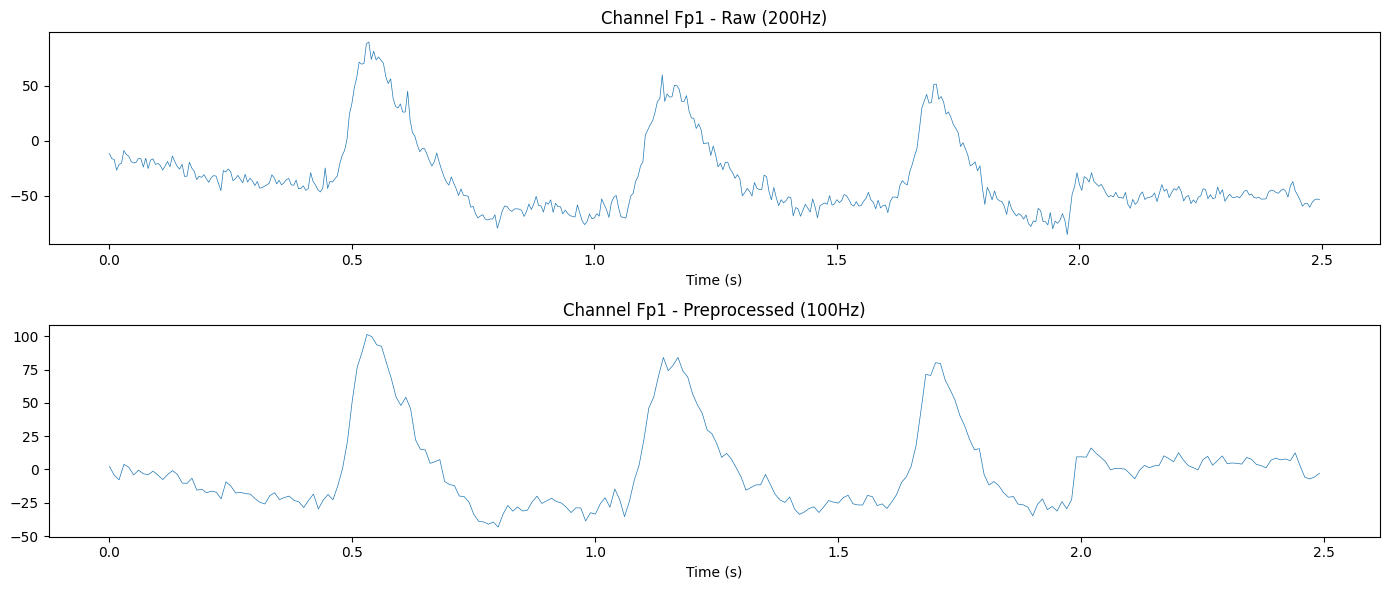

✓ Preprocessing test passed


In [4]:
def bandpass_filter(data, low, high, fs, order=4):
    """Bandpass filter (channels, timepoints)"""
    sos = butter(order, [low, high], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, data, axis=1)

def notch_filter(data, freq, q, fs):
    """Notch filter to remove line noise"""
    b, a = iirnotch(freq, q, fs)
    return filtfilt(b, a, data, axis=1)

def downsample(data, original_fs, target_fs):
    """Downsample with anti-aliasing"""
    g = gcd(original_fs, target_fs)
    up = target_fs // g
    down = original_fs // g
    return resample_poly(data, up, down, axis=1)

def preprocess_eeg(eeg_data):
    """
    Full preprocessing pipeline for one trial.
    Input:  (62, timepoints) @ 200Hz
    Output: (62, new_timepoints) @ 100Hz
    """
    # 1. Bandpass 1-45Hz
    filtered = bandpass_filter(eeg_data, BANDPASS_LOW, BANDPASS_HIGH, ORIGINAL_FS, BANDPASS_ORDER)
    # 2. Notch 50Hz
    filtered = notch_filter(filtered, NOTCH_FREQ, NOTCH_Q, ORIGINAL_FS)
    # 3. Downsample 200→100Hz
    downsampled = downsample(filtered, ORIGINAL_FS, TARGET_FS)
    return downsampled

# Test pada 1 trial
if eeg is not None:
    processed = preprocess_eeg(eeg)
    print(f"Raw:        {eeg.shape} @ {ORIGINAL_FS}Hz")
    print(f"Preprocessed: {processed.shape} @ {TARGET_FS}Hz")
    print(f"Duration: {processed.shape[1]/TARGET_FS:.1f}s")
    
    # Visualisasi before/after
    fig, axes = plt.subplots(2, 1, figsize=(14, 6))
    t_raw = np.arange(eeg.shape[1]) / ORIGINAL_FS
    t_proc = np.arange(processed.shape[1]) / TARGET_FS
    
    axes[0].plot(t_raw[:500], eeg[0, :500], linewidth=0.5)
    axes[0].set_title(f"Channel Fp1 - Raw ({ORIGINAL_FS}Hz)")
    axes[0].set_xlabel("Time (s)")
    
    axes[1].plot(t_proc[:250], processed[0, :250], linewidth=0.5)
    axes[1].set_title(f"Channel Fp1 - Preprocessed ({TARGET_FS}Hz)")
    axes[1].set_xlabel("Time (s)")
    
    plt.tight_layout()
    plt.savefig(r"D:\Skripsi\new_data\00_preprocessing\output\preprocess_comparison.png", dpi=150)
    plt.show()
    print("✓ Preprocessing test passed")


## 4. Preprocessing Semua Subjek

In [5]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

metadata = {"original_fs": ORIGINAL_FS, "target_fs": TARGET_FS, "subjects": {}}
total_trials = 0
start_all = time.time()

for subject_id in range(1, 16):
    sessions = SUBJECT_SESSIONS[subject_id]
    
    for session_date in sessions:
        out_dir = os.path.join(OUTPUT_DIR, f"subject_{subject_id:02d}", f"session_{session_date}")
        os.makedirs(out_dir, exist_ok=True)
        
        n_saved = 0
        for trial_idx in range(15):
            eeg, label = load_trial_eeg(subject_id, session_date, trial_idx)
            if eeg is None:
                continue
            
            processed = preprocess_eeg(eeg)
            filepath = os.path.join(out_dir, f"trial_{trial_idx+1:02d}.npy")
            np.save(filepath, processed)
            n_saved += 1
            total_trials += 1
        
        sess_key = f"subject_{subject_id:02d}/session_{session_date}"
        print(f"  {sess_key}: {n_saved} trials", flush=True)

total_time = time.time() - start_all
metadata["total_trials"] = total_trials
metadata["total_time_min"] = round(total_time / 60, 1)

# Save metadata
meta_path = os.path.join(OUTPUT_DIR, "preprocess_metadata.json")
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n{'='*50}")
print(f"✓ Done! {total_trials} trials in {total_time/60:.1f} minutes")
print(f"  Metadata: {meta_path}")


  subject_01/session_20131027: 15 trials
  subject_01/session_20131030: 15 trials
  subject_01/session_20131107: 15 trials
  subject_02/session_20140404: 15 trials
  subject_02/session_20140413: 15 trials
  subject_02/session_20140419: 15 trials
  subject_03/session_20140603: 15 trials
  subject_03/session_20140611: 15 trials
  subject_03/session_20140629: 15 trials
  subject_04/session_20140621: 15 trials
  subject_04/session_20140702: 15 trials
  subject_04/session_20140705: 15 trials
  subject_05/session_20140411: 15 trials
  subject_05/session_20140418: 15 trials
  subject_05/session_20140506: 15 trials
  subject_06/session_20130712: 15 trials
  subject_06/session_20131016: 15 trials
  subject_06/session_20131113: 15 trials
  subject_07/session_20131027: 15 trials
  subject_07/session_20131030: 15 trials
  subject_07/session_20131106: 15 trials
  subject_08/session_20140511: 15 trials
  subject_08/session_20140514: 15 trials
  subject_08/session_20140521: 15 trials
  subject_09/ses

## 5. Verifikasi Hasil

In [6]:
# Verify: load one preprocessed file and check
sample_path = os.path.join(OUTPUT_DIR, "subject_01", "session_20131027", "trial_01.npy")
if os.path.exists(sample_path):
    sample = np.load(sample_path)
    print(f"✓ Sample loaded: {sample_path}")
    print(f"  Shape: {sample.shape}")
    print(f"  Dtype: {sample.dtype}")
    print(f"  Min/Max: {sample.min():.4f} / {sample.max():.4f}")
    print(f"  Mean/Std: {sample.mean():.4f} / {sample.std():.4f}")
    print(f"  FS: {TARGET_FS}Hz, Duration: {sample.shape[1]/TARGET_FS:.1f}s")
else:
    print("Sample not found — preprocessing may not have completed")

# Count total files
total_files = 0
for root, dirs, files in os.walk(OUTPUT_DIR):
    total_files += sum(1 for f in files if f.endswith('.npy'))
print(f"\n✓ Total .npy files: {total_files}")
print(f"  Expected: 675 (15 subjects × 3 sessions × 15 trials)")


✓ Sample loaded: D:\Skripsi\new_data\00_preprocessing\output\preprocessed_eeg\subject_01\session_20131027\trial_01.npy
  Shape: (62, 23501)
  Dtype: float64
  Min/Max: -4502.3382 / 16613.5948
  Mean/Std: 0.0340 / 359.2857
  FS: 100Hz, Duration: 235.0s

✓ Total .npy files: 630
  Expected: 675 (15 subjects × 3 sessions × 15 trials)
